# Esame Laboratorio di Programmazione II - 27/06/2025


In [194]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy as sp

## Esercizio 1

Crea un array NumPy con i prezzi (in euro) di 5 libri: **14.99, 22.50, 9.75, 18.00, 31.20, 12.80, 24.90, 8.40, 19.99, 27.30**

1. Calcola il prezzo medio dei libri
2. Seleziona i libri con un prezzo maggiore della media.
3. Crea un nuovo array che applica uno sconto del 10% solo ai libri che costano più della media.

In [9]:
prezzi = np.array([14.99, 22.50, 9.75, 18.00, 31.20, 12.80, 24.90, 8.40, 19.99, 27.30])
print(prezzi)
media = sum(prezzi)/len(prezzi)
print("media {}".format(media))

print(prezzi[prezzi>media])

prezzi[prezzi>media]*=90/100

print(prezzi)

[14.99 22.5   9.75 18.   31.2  12.8  24.9   8.4  19.99 27.3 ]
media 18.983000000000004
[22.5  31.2  24.9  19.99 27.3 ]
[14.99  20.25   9.75  18.    28.08  12.8   22.41   8.4   17.991 24.57 ]


## Esercizio 2

Simula 1000 lanci di una moneta che ad ogni lancio ha il doppio di probabilità di risultare croce invece che testa. Ogni lancio è rappresentato da 1 (testa) o 0 (croce).

1. Crea un array NumPy contenente i risultati.
2. Calcola la proporzione di teste dopo ogni 50 lanci cumulativi.
3. Crea un grafico della proporzione cumulativa nel tempo (dopo 50 lanci, dopo 100, dopo 150,...).

In [50]:
np.random.seed(0)

vec_prob = [2/3, 1/3]
a = [0,1]

res = np.random.choice(a=a, size=1000, p=vec_prob)
print(res)

#calcolare la proporzione di teste dopo ogni 50 lanci cumulativi
csum = np.cumsum(res)
csum

csum_list_testa=[]
for i in range(int(1000/50)):
    csum_list_testa.append(csum[50*i-1]/(50*i))

print(csum_list_testa)

csum_list_testa =np.reshape(csum_list_testa, (1,20))

[0 1 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 1 1 1 1 1 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0
 0 1 1 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0
 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0 1 0 1 1 0 0 0 0 0 1 0
 1 1 0 1 0 1 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1
 1 1 0 1 0 0 0 1 1 0 0 0 1 0 1 1 1 1 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1
 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 1 0 1
 0 1 0 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 1
 0 0 0 0 1 1 1 0 0 0 0 1 1 0 1 0 1 1 1 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0
 0 1 1 1 1 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 1 0
 1 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1
 1 0 1 0 0 0 1 1 0 0 1 0 1 0 1 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0
 0 0 1 1 1 1 0 1 0 0 1 0 1 0 1 1 0 0 0 1 0 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0
 0 0 0 0 0 0 1 1 0 0 0 1 

C:\Users\margh\AppData\Local\Temp\ipykernel_28652\1075526047.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  csum_list_testa.append(csum[50*i-1]/(50*i))


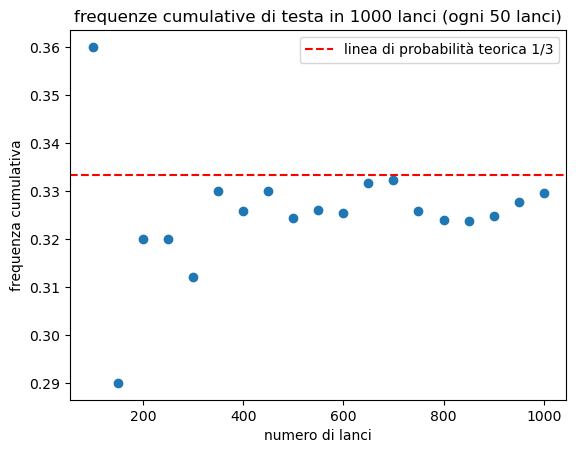

In [53]:
#crea un grafico della proporzione cumulativa nel tempo
x = np.linspace(50, 1000, 20, dtype=int)
x

plt.scatter(x=x, y=csum_list_testa)
plt.title("frequenze cumulative di testa in 1000 lanci (ogni 50 lanci)")
plt.xlabel("numero di lanci")
plt.ylabel("frequenza cumulativa")
plt.axhline(y=1/3, linestyle="--",color="r", label="linea di probabilità teorica 1/3")
plt.legend()

## Esercizio 3

Crea una funzione di nome **mat_normalizzata** che prende come input una matrice e ritorna la matrice normalizzata.

La funzione deve quindi:
1. Calcolare la media e la deviazione standard della matrice.
2. Normalizzare la matrice sottraendo la media e dividendo per la deviazione standard.

Testa La funzione con un array NumPy 6x10 con numeri campionati da una distribuzione normale (media=5, std=2).

In [ ]:
def mat_noramalizzata(matrix):
    media = np.mean(matrix)
    std_dev = np.std(matrix)
    matrix_new = (matrix - media)/std_dev

    return matrix_new

numeri = np.random.normal(5, 2, 6*10)
a = np.reshape(numeri, (6,10))

mat_noramalizzata(a)

array([[ 0.08032127,  1.59715769,  0.38335958, -0.43228663, -1.51977222,
         0.03956018,  1.55306407, -0.81710797,  0.41175448,  0.04178985],
       [ 0.84946002, -1.33304087,  2.78974559, -1.95367925, -0.75845868,
         0.9470192 ,  0.10796764,  0.80559018, -0.92925096, -0.37809319],
       [-0.26422801,  1.77273679,  0.62301604,  0.76200742, -1.14095516,
         0.98730001,  0.01488444,  1.53710418,  2.35464236, -0.68155342],
       [-0.81177211, -1.41060802, -0.46806673, -0.78001109,  0.19008743,
        -0.46935837, -0.75328877,  1.11250179, -1.50720218,  0.28637849],
       [-0.8112993 ,  0.66741701,  1.53202328, -0.67675543,  0.29674623,
        -0.04632651, -1.3260662 ,  0.03477732,  0.09800845,  0.25990348],
       [-0.53978361, -0.1570043 , -1.78158015, -0.74872929,  0.44710188,
         0.88733908, -0.83271923, -0.14323936,  0.01811796, -0.01664638]])

## Esercizio 4

Utilizza il dataset `books.csv`.

1. **Crea una nuova colonna** chiamata `engagement_score`, definita come:

   $$
   \texttt{engagement\_score} = \texttt{average\_rating} \times \log_{10}(1 + \texttt{ratings\_count})
   $$

   *(Un indicatore che tiene conto sia della qualità (valutazione media), sia della quantità di voti. Il logaritmo serve ad attenuare l'effetto dei libri estremamente popolari.)*

2. Trova il **libro con il valore massimo** di `engagement_score`.

3. **Filtra i libri** con una valutazione media (`average_rating`) **maggiore di 4.5**.

4. **Crea un grafico a barre** con i 10 libri con il valore più alto di `engagement_score`.

5. **Crea un grafico a linee** della `average_rating`, ordinando i libri per `ratings_count` crescente.


In [ ]:
data = pd.read_csv("books.csv")
data.head()

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


In [65]:
data['engagement_score'] = data.average_rating*np.log10(1+data.ratings_count)
data.head(10)

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url,engagement_score
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...,28.988975
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...,29.583684
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...,23.516862
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...,27.646121
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...,25.007753
5,6,11870085,11870085,16827462,226,525478817,9.780525e+12,John Green,2012.0,The Fault in Our Stars,...,2478609,140739,47994,92723,327550,698471,1311871,https://images.gr-assets.com/books/1360206420m...,https://images.gr-assets.com/books/1360206420s...,27.137917
6,7,5907,5907,1540236,969,618260307,9.780618e+12,J.R.R. Tolkien,1937.0,The Hobbit or There and Back Again,...,2196809,37653,46023,76784,288649,665635,1119718,https://images.gr-assets.com/books/1372847500m...,https://images.gr-assets.com/books/1372847500s...,26.844315
7,8,5107,5107,3036731,360,316769177,9.780317e+12,J.D. Salinger,1951.0,The Catcher in the Rye,...,2120637,44920,109383,185520,455042,661516,709176,https://images.gr-assets.com/books/1398034300m...,https://images.gr-assets.com/books/1398034300s...,23.916917
8,9,960,960,3338963,311,1416524797,9.781417e+12,Dan Brown,2000.0,Angels & Demons,...,2078754,25112,77841,145740,458429,716569,680175,https://images.gr-assets.com/books/1303390735m...,https://images.gr-assets.com/books/1303390735s...,24.260062
9,10,1885,1885,3060926,3455,679783261,9.780680e+12,Jane Austen,1813.0,Pride and Prejudice,...,2191465,49152,54700,86485,284852,609755,1155673,https://images.gr-assets.com/books/1320399351m...,https://images.gr-assets.com/books/1320399351s...,26.748757


In [67]:
#libro con il valore massimo di engagement score
data.engagement_score.argmax()
data.original_title[data.engagement_score.argmax()]

"Harry Potter and the Philosopher's Stone"

In [68]:
data[data.average_rating>4.5]

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url,engagement_score
17,18,5,5,2402163,376,043965548X,9.780440e+12,"J.K. Rowling, Mary GrandPré, Rufus Beck",1999.0,Harry Potter and the Prisoner of Azkaban,...,1969375,36099,6716,20413,166129,509447,1266670,https://images.gr-assets.com/books/1499277281m...,https://images.gr-assets.com/books/1499277281s...,28.371937
23,24,6,6,3046572,332,439139600,9.780439e+12,"J.K. Rowling, Mary GrandPré",2000.0,Harry Potter and the Goblet of Fire,...,1868642,31084,6676,20210,151785,494926,1195045,https://images.gr-assets.com/books/1361482611m...,https://images.gr-assets.com/books/1361482611s...,28.284381
24,25,136251,136251,2963218,263,545010225,9.780545e+12,"J.K. Rowling, Mary GrandPré",2007.0,Harry Potter and the Deathly Hallows,...,1847395,51942,9363,22245,113646,383914,1318227,https://images.gr-assets.com/books/1474171184m...,https://images.gr-assets.com/books/1474171184s...,28.776483
26,27,1,1,41335427,275,439785960,9.780440e+12,"J.K. Rowling, Mary GrandPré",2005.0,Harry Potter and the Half-Blood Prince,...,1785676,27520,7308,21516,136333,459028,1161491,https://images.gr-assets.com/books/1361039191m...,https://images.gr-assets.com/books/1361039191s...,28.261523
134,135,62291,62291,1164465,175,055357342X,9.780554e+12,George R.R. Martin,2000.0,A Storm of Swords,...,527644,19497,1456,4820,36418,149268,335682,https://images.gr-assets.com/books/1497931121m...,https://images.gr-assets.com/books/1497931121s...,25.747221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9568,9569,32075671,32075671,49638190,36,62498533,9.780062e+12,Angie Thomas,2017.0,The Hate U Give,...,38333,9038,208,321,1814,9207,26783,https://images.gr-assets.com/books/1476284759m...,https://images.gr-assets.com/books/1476284759s...,20.851742
9711,9712,17333174,17333174,24064358,14,425270696,9.780425e+12,Ilona Andrews,2016.0,Magic Binds,...,14525,1656,28,66,894,4089,9448,https://images.gr-assets.com/books/1454609590m...,https://images.gr-assets.com/books/1454609590s...,18.466276
9780,9781,6081686,6081686,6258393,15,142781404X,9.781428e+12,Hiro Fujiwara,2007.0,会長はメイド様! 2,...,10514,123,60,186,992,2175,7101,https://s.gr-assets.com/assets/nophoto/book/11...,https://s.gr-assets.com/assets/nophoto/book/50...,18.089067
9805,9806,6801614,6801614,7008132,18,1421534541,9.781422e+12,Eiichirō Oda,2005.0,ONE PIECE 38,...,8706,34,61,112,589,1435,6509,https://images.gr-assets.com/books/1397155647m...,https://images.gr-assets.com/books/1397155647s...,18.179442


1     29.583684
0     28.988975
24    28.776483
17    28.371937
23    28.284381
26    28.261523
20    27.827688
3     27.646121
30    27.524091
22    27.313623
Name: engagement_score, dtype: float64


Text(0.5, 0, 'identificativo del libro')

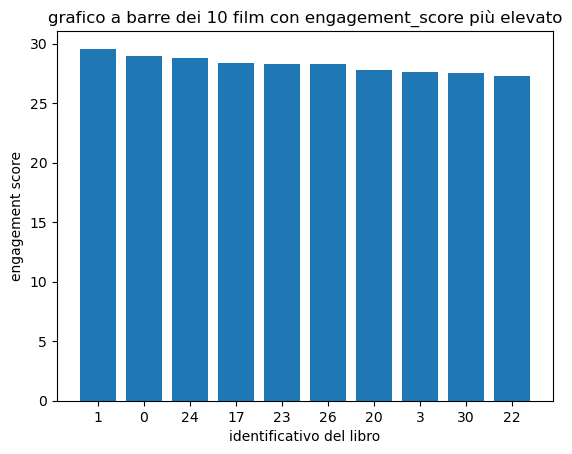

In [87]:
subset = data.engagement_score.nlargest(10)
print(subset)
indici = [str(i) for i in subset.index]

plt.bar(indici, subset.values)
plt.title('grafico a barre dei 10 film con engagement_score più elevato')
plt.ylabel('engagement score')
plt.xlabel('identificativo del libro')

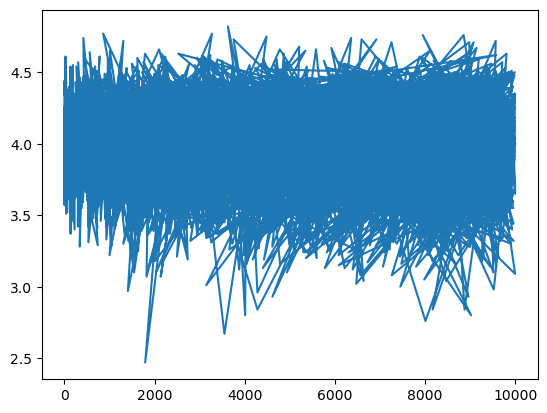

In [95]:
data_sorted = data.sort_values(by='ratings_count', ascending=True)
plt.plot(data_sorted.average_rating, linestyle='-')

## Esercizio 5
Utilizza il dataset `adult.csv`.
Contiene informazioni demografiche su adulti negli Stati Uniti. Le colonne rilevanti sono:
- `age`: età (integer)
- `workclass`, `education`, `marital-status`, `occupation`, `race`, `sex`
- `hours-per-week`: ore lavorate a settimana
- `income`: `>50K` o `<=50K` (target)

1. Quante **righe e colonne** ha il dataset?
2. Quanti **valori mancanti** ci sono per colonna?
3. **Sostituisci i valori mancanti** nelle colonne categoriche (workclass, occupation, native-country) con il valore più frequente (la moda).
4. Calcola l’**età media** (`age`) per sesso (`sex`)
5. Trova la % di persone che guadagnano **>50K** per sesso.
7. Crea una **colonna `age_group`** raggruppando le età in fasce: `'<30'`, `'30-50'`, `'>50'`.
8. **Crea**:
   - un grafico **a barre** con % di reddito `>50K` per fascia di età.
   - un **boxplot** delle ore lavorate (`hours-per-week`) per gruppo reddito (<=50, >50).


In [106]:
data = pd.read_csv('adult.csv')
data.head()
data.info() #15 variabili e 32561 osservazioni

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.5 MB


In [111]:
print(pd.isna(data).sum()) #nessun na per colonna

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [113]:
print(data.groupby(by='sex')['age'].mean())

sex
Female    36.858230
Male      39.433547
Name: age, dtype: float64


In [155]:
data.head()
data.income.unique()
data_sub = data[data.income==' >50K']


print("percentuale di maschi con income >50k: {}".format((len(data_sub[data_sub.sex == ' Male'])/len(data_sub)*100)))
print("percentuale di femmine con income >50k: {}".format((len(data_sub[data_sub.sex == ' Female'])/len(data_sub)*100)))



percentuale di maschi con income >50k: 84.96365259533223
percentuale di femmine con income >50k: 15.036347404667772


In [160]:
#7. Crea una **colonna `age_group`** raggruppando le età in fasce: `'<30'`, `'30-50'`, `'>50'`.
data['age_group']=pd.cut(data.age, bins=[-float('inf'),30,50, + float('inf')], labels=['1', '2', '3'])

Text(0.5, 1.0, "grafico a basse com la percenuale di reddito >50K suddivisa per fasce d'età")

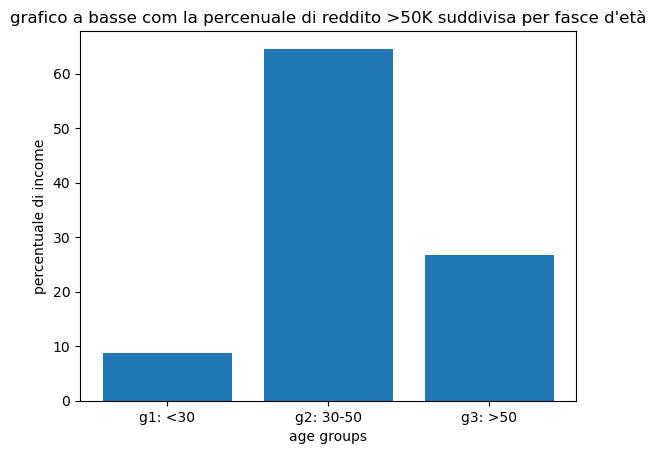

In [ ]:
# 8. **Crea**:
#    - un grafico **a barre** con % di reddito `>50K` per fascia di età.
data_sub = data[data['income']==' >50K']
g1 = len(data_sub[data_sub.age_group == '1'])/len(data_sub)*100
g2 = len(data_sub[data_sub.age_group == '2'])/len(data_sub)*100
g3 = len(data_sub[data_sub.age_group == '3'])/len(data_sub)*100

plt.bar(['g1: <30','g2: 30-50','g3: >50'], [g1,g2,g3])
plt.xlabel('age groups')
plt.ylabel('percentuale di income')
plt.title("grafico a basse com la percenuale di reddito >50K suddivisa per fasce d'età")


<Axes: xlabel='income', ylabel='hours-per-week'>

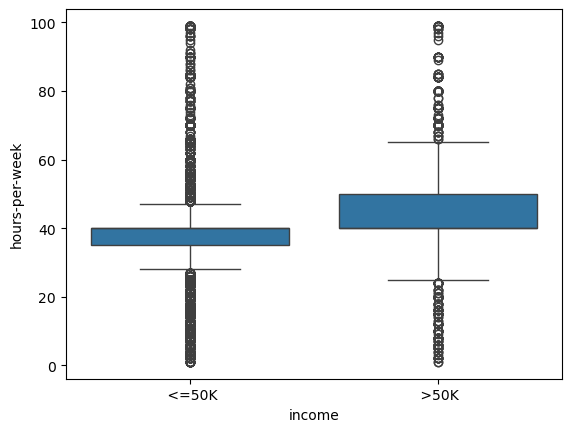

In [192]:
#    - un **boxplot** delle ore lavorate (`hours-per-week`) per gruppo reddito (<=50, >50).
sns.boxplot(data=data, x='income', y='hours-per-week')


## Esercizio 6

Genera due array:

`x = np.linspace(0, 5, 80)`  
`y = 2.5 * x + 1.2 + np.random.normal(0, 0.5, 80)`

1. Usa `scipy.optimize.curve_fit` per stimare i parametri della retta.
2. Plotta i punti originali e la retta ottenuta.
3. Calcola MAE e RMSE tra i valori reali e quelli stimati.

In [ ]:
x = np.linspace(0, 5, 80) 
y = 2.5 * x + 1.2 + np.random.normal(0, 0.5, 80)


In [199]:
def lineare(x, m, q):
    return m*x + q

popt, _ = sp.optimize.curve_fit(lineare, x, y)
m = popt[0]
q=popt[1]

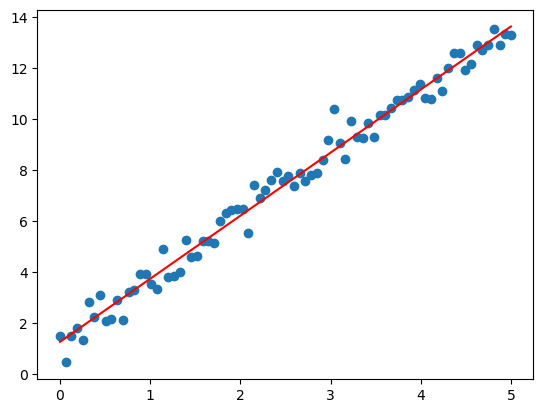

In [202]:
plt.scatter(x, y)
plt.plot(x, lineare(x, m, q), color='r')

In [203]:
y_pred = lineare(x, m, q)
mae = np.mean(np.abs(y - y_pred))
rmse = np.sqrt(np.mean((y - y_pred)**2))
print(mae, rmse)

0.3701367949523481 0.46445894562614326
